# Regressão Linear

In [199]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

movies = pd.read_csv("moviesTMBD.csv")

In [200]:
movies.head(10)

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901
5,5,424,Schindler's List,35.8510,False,en,The true story of how businessman Oskar Schind...,1993-12-15,8.569,17447
6,6,389,12 Angry Men,22.8937,False,en,The defense and the prosecution have rested an...,1957-04-10,8.600,9977
7,7,1330021,Remarkably Bright Creatures,96.5828,False,en,Through unlikely bonds formed during night shi...,2026-05-07,8.546,393
8,8,129,Spirited Away,32.2851,False,ja,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,8.534,18302
9,9,155,The Dark Knight,45.5176,False,en,Batman raises the stakes in his war on crime. ...,2008-07-16,8.530,35750


#### Limpando o dataset
- Remoção de title com nome de Return
- Remoção de overview com valores NaN

In [201]:
movies_filtrado = movies[movies['title']!='Return']
movies_filtrado = movies_filtrado.dropna(subset=['overview','release_date'])

#### Adicionando features
- Alterando a coluna 'release_date' para a idade do filme (primeiro tivemos que converter o tipo da coluna para datetime)

In [202]:
# Convertendo para datetime
movies_filtrado = movies_filtrado.copy()

movies_filtrado['release_date'] = pd.to_datetime(
    movies_filtrado['release_date'],
)

# Idade do filme é baseada na conta: idade = (dia_atual - dia_do_filme) / 365.25 
movies_filtrado['movie_age']=(
    pd.Timestamp.today()-movies_filtrado['release_date']
).dt.days /365.25

# Removendo a coluna antida 'release_date'
movies_filtrado = movies_filtrado.drop('release_date', axis=1)

#### Verificando Outliers
1) Scatter plot da relação de 'populariry' e 'vote_counts'
- Essa relação nos mostra os outliers existentes na coluna 'popularity'

<Axes: xlabel='vote_count', ylabel='popularity'>

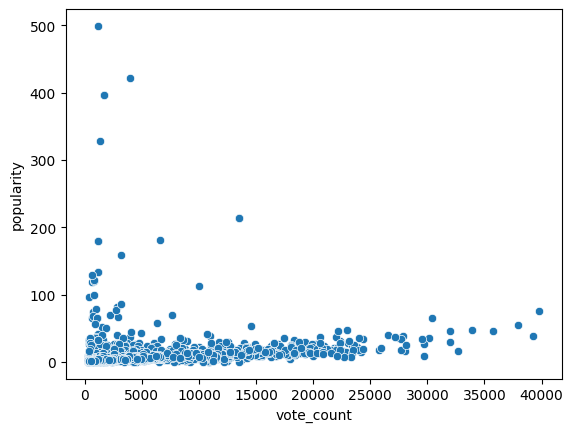

In [203]:
sns.scatterplot(data=movies_filtrado,
                x='vote_count',
                y='popularity')

#### Tratando Outliers
- Transformando os dados para uma escala logarítmica

<Axes: xlabel='log_vote_count', ylabel='log_popularity'>

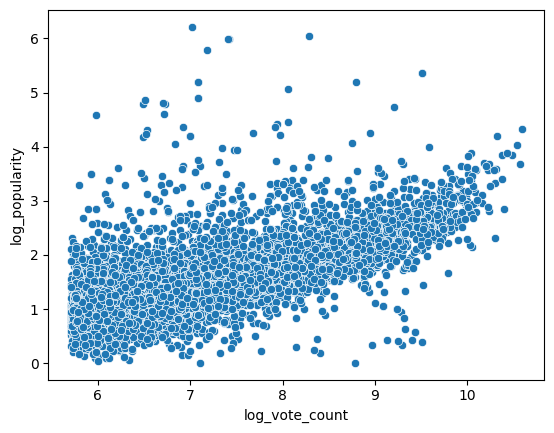

In [204]:
movies_filtrado['log_popularity'] = np.log1p(movies_filtrado['popularity'])
movies_filtrado['log_vote_count'] = np.log1p(movies_filtrado['vote_count'])
sns.scatterplot(data=movies_filtrado,
                x='log_vote_count',
                y='log_popularity')

## Treinamento do modelo de Regressão Linear

#### Divisão dos dados treino e test

In [223]:
from sklearn.model_selection import train_test_split

# Definição das variáveis
X = movies_filtrado[['log_vote_count','vote_average','movie_age']]
y = movies_filtrado['log_popularity']

# Divisão do conjunto de dados em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Aplicando Regressão Linear nos dados
- Objetivo: queremos preditar a variável 'popularity'
- Utilizamos: vote_count, vote_average e movie_age

In [224]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

fitted = model.predict(X_test)

# Residuals são os erros cometidos pelo modelo a cada observação
residuals = y_test-fitted

#### Resultados

In [225]:
from sklearn.metrics import r2_score, mean_absolute_error

print(f'Intercept(b0): {model.intercept_:.3f}')
print(f'Slope/coeficiente (b1): {model.coef_}')

print(r2_score(y_test, fitted))
print(mean_absolute_error(y_test, fitted))

Intercept(b0): -2.065
Slope/coeficiente (b1): [ 0.38978256  0.12432663 -0.00281851]
0.4767108156589258
0.30126574599890926


#### Plotando resultado

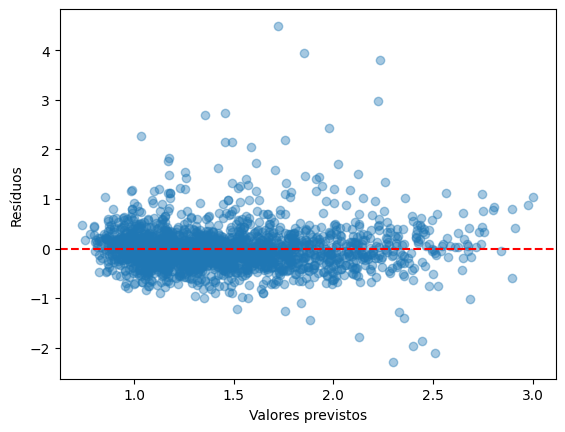

In [226]:
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()